In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('../kaggle_prediction_library/') 
import preprocess
import feature_engineering
import submission
import validation
from sklearn.model_selection import train_test_split

# from hyperopt import tpe, fmin, Trials
# import hyperopt.hp as hp

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
from sklearn.feature_selection import chi2
from sklearn.metrics import r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import brier_score_loss
from sklearn.pipeline import make_pipeline



In [2]:
to_predict_mens = pd.read_csv("to_predict_mens.csv")

In [3]:
to_predict_mens[(to_predict_mens["GameRound"] == 1) & (to_predict_mens["Season"] == 2024)][["t1_TeamName", "t2_TeamName", "final_odds"]].head()

,t1_TeamName,t2_TeamName,final_odds
1318,Arizona,Long Beach St,-20.0
1319,Creighton,Akron,-12.5
1320,Dayton,Nevada,1.0
1321,Duquesne,BYU,7.5
1322,Gonzaga,McNeese St,-6.5


In [4]:
pd.set_option('display.max_columns', None)
1345
to_predict_mens[(to_predict_mens["Season"] == 2024)][["Team1", "t1_TeamName", "t1_adj_margin"]].drop_duplicates().sort_values(by="t1_adj_margin")

,Team1,t1_TeamName,t1_adj_margin
1317,1212,Grambling,-11.277963
2696,1224,Howard,-8.255369
1315,1447,Wagner,-8.062748
2719,1391,Stetson,-6.125959
2698,1286,Montana St,-4.311703
...,...,...,...
1324,1235,Iowa St,28.618729
2721,1388,St Mary's CA,28.632492
2730,1120,Auburn,28.847706
1338,1163,Connecticut,29.752956


In [5]:
to_predict_mens[(to_predict_mens["GameRound"] == 1) & (to_predict_mens["Season"] == 2024)
                & (to_predict_mens["Team2"] == 1345)]

,Unnamed: 0,type,ID,Pred,Season,Team1,Team2,Outcome,Gender,margin,t1_TeamName,t1_FirstD1Season,t1_LastD1Season,t2_TeamName,t2_FirstD1Season,t2_LastD1Season,final_odds,GameRound,t1_FGM,t1_FGA,t1_FGM3,t1_FGA3,t1_OR,t1_Ast,t1_TO,t1_Stl,t1_PF,t1_FTA,t1_FTM,t1_PointDiff,t2_FGM,t2_FGA,t2_FGM3,t2_FGA3,t2_OR,t2_Ast,t2_TO,t2_Stl,t2_PF,t2_FTA,t2_FTM,t2_PointDiff,t1_OrdinalRank,t2_OrdinalRank,t1_Seed,t2_Seed,seed_diff,t1_adj_oe,t1_adj_de,t1_adj_margin,t2_adj_oe,t2_adj_de,t2_adj_margin,t1_final_rank,t2_final_rank,t1_top8_TO_stdev,t1_top5_PRPG!_median,t1_top3_DR_median,t1_top5_STL_cv,t1_top3_Min%_median,t1_top8_TS_gini,t1_top3_USG_gini,t1_top8_BPM_weighted_mean,t2_top8_TO_stdev,t2_top5_PRPG!_median,t2_top3_DR_median,t2_top5_STL_cv,t2_top3_Min%_median,t2_top8_TS_gini,t2_top3_USG_gini,t2_top8_BPM_weighted_mean
2726,2728,Historical,2024_1212_1345,NaN,2024,1212,1345,0,M,-28,Grambling,1985,2025,Purdue,1985,2025,25.5,1,22.580645,52.354839,5.322581,15.612903,7.741935,9.16129,12.741935,7.129032,16.16129,20.741935,14.645161,-3.741935,28.515152,58.393939,8.333333,20.424242,11.030303,18.393939,10.969697,5.666667,14.363636,25.0,18.030303,13.242424,25.0,2.0,16,1,15,101.155352,112.433315,-11.277963,127.87684,100.690725,27.186115,66.780628,94.318459,5.996874,1.1,9.6,0.41779,66.6,0.050342,0.073737,-1.223557,3.197045,3.2,16.1,0.590937,77.4,0.10143,0.115556,7.184446


### Prepare data 

In [19]:
def prepare_data(to_predict_mens, season):

    to_predict_mens_first_round_train = to_predict_mens[(to_predict_mens["GameRound"] == 1)
                                                        & (to_predict_mens.Season < season)
                                                        & (to_predict_mens.Season >= 2008)
                                                        ].copy()
    
    to_predict_mens_train = to_predict_mens[(to_predict_mens.Season < season)
                                            & (to_predict_mens.Season >= 2008)].copy()

    to_predict_mens_first_round_test = to_predict_mens[(to_predict_mens.Season == season)
                                                    & (to_predict_mens.GameRound == 1)
                                                    & (to_predict_mens.final_odds.notnull())
                                                    ].copy()

    to_predict_mens_other_rounds_test = to_predict_mens[(to_predict_mens.Season == season)
                                                    & (to_predict_mens.GameRound > 1)
                                                    ].copy()
    
    return to_predict_mens_first_round_train, to_predict_mens_train, to_predict_mens_first_round_test, to_predict_mens_other_rounds_test
    


In [204]:
statistics_model_first_round_features = ['t1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean',
    't1_top8_TO_stdev', 't2_top8_TO_stdev',
    't1_top5_PRPG!_median', 't2_top5_PRPG!_median',
    't1_top3_DR_median', 't2_top3_DR_median',
    't1_top5_STL_cv', 't2_top5_STL_cv',
    't1_top3_Min%_median', 't2_top3_Min%_median',
    't1_top8_TS_gini', 't2_top8_TS_gini',
    't1_top3_USG_gini', 't2_top3_USG_gini',
    't1_OrdinalRank', 't2_OrdinalRank'
    ,]

statistics_model_first_round = train_statistics_model(to_predict_mens_first_round_train, statistics_model_first_round_features)
print(to_predict_mens_first_round_train.t1_top8_BPM_weighted_mean.mean(), to_predict_mens_first_round_train.t2_top8_BPM_weighted_mean.mean(), to_predict_mens_first_round_train.t1_top8_BPM_weighted_mean.std(), to_predict_mens_first_round_train.t2_top8_BPM_weighted_mean.std())
scaler = statistics_model_first_round.named_steps['standardscaler']
results = scaler.transform(to_predict_mens_first_round_test[statistics_model_first_round_features])
results[0].mean(), results[1].mean() 


3.777159203553301 3.777159203553302 1.874154037251757 1.874154037251757


(-0.2024805874864447, 0.2576928704331698)

In [215]:
to_predict_mens_first_round_test

,Unnamed: 0,type,ID,Pred,Season,Team1,Team2,Outcome,Gender,margin,t1_TeamName,t1_FirstD1Season,t1_LastD1Season,t2_TeamName,t2_FirstD1Season,t2_LastD1Season,final_odds,GameRound,t1_FGM,t1_FGA,t1_FGM3,t1_FGA3,t1_OR,t1_Ast,t1_TO,t1_Stl,t1_PF,t1_FTA,t1_FTM,t1_PointDiff,t2_FGM,t2_FGA,t2_FGM3,t2_FGA3,t2_OR,t2_Ast,t2_TO,t2_Stl,t2_PF,t2_FTA,t2_FTM,t2_PointDiff,t1_OrdinalRank,t2_OrdinalRank,t1_Seed,t2_Seed,seed_diff,t1_adj_oe,t1_adj_de,t1_adj_margin,t2_adj_oe,t2_adj_de,t2_adj_margin,t1_final_rank,t2_final_rank,t1_top8_TO_stdev,t1_top5_PRPG!_median,t1_top3_DR_median,t1_top5_STL_cv,t1_top3_Min%_median,t1_top8_TS_gini,t1_top3_USG_gini,t1_top8_BPM_weighted_mean,t2_top8_TO_stdev,t2_top5_PRPG!_median,t2_top3_DR_median,t2_top5_STL_cv,t2_top3_Min%_median,t2_top8_TS_gini,t2_top3_USG_gini,t2_top8_BPM_weighted_mean
1318,1319,Historical,2024_1112_1253,0.981608,2024,1112,1253,1,M,20,Arizona,1985,2025,Long Beach St,1985,2025,-20.0,1,31.545455,64.515152,7.818182,21.060606,11.545455,18.575758,11.757576,8.272727,16.333333,23.696970,17.030303,15.696970,27.272727,61.272727,5.424242,17.333333,10.454545,15.030303,12.000000,7.636364,17.454545,23.333333,16.575758,0.606061,3.0,25.0,2,15,-13,122.877155,95.548918,27.328237,112.196844,110.084666,2.112178,92.605689,71.774988,1.961146,3.6,10.6,0.168673,72.8,0.034816,0.069668,6.289426,4.232150,2.4,19.7,0.276065,73.8,0.082246,0.071672,0.097263
1319,1320,Historical,2024_1166_1103,0.900635,2024,1166,1103,1,M,17,Creighton,1985,2025,Akron,1985,2025,-12.5,1,29.218750,60.062500,10.593750,29.343750,7.125000,17.125000,9.812500,3.968750,11.312500,14.718750,11.500000,10.812500,25.562500,56.343750,7.500000,23.406250,8.187500,12.312500,10.812500,5.343750,16.968750,18.937500,13.718750,5.531250,8.0,25.0,3,14,-11,123.765679,100.150459,23.615220,109.143202,103.065096,6.078106,89.194748,75.918843,5.269488,4.4,14.9,0.354243,88.9,0.051578,0.047816,5.674948,4.896874,1.9,10.9,0.479070,71.2,0.074076,0.086629,1.204425
1320,1321,Historical,2024_1173_1305,0.378176,2024,1173,1305,1,M,3,Dayton,1985,2025,Nevada,1985,2025,1.0,1,25.354839,53.161290,9.516129,23.677419,7.064516,14.774194,9.645161,5.387097,13.419355,19.774194,14.516129,8.451613,25.593750,54.218750,6.656250,18.218750,7.718750,14.875000,9.687500,6.062500,17.906250,25.031250,18.093750,8.625000,25.0,25.0,7,10,-3,125.053728,105.360003,19.693724,120.572166,101.078262,19.493905,85.258089,84.394558,5.804726,3.6,16.0,0.322329,80.2,0.069733,0.144796,3.864630,4.225055,3.2,10.9,0.250293,75.9,0.033048,0.084317,4.043978
1321,1322,Historical,2024_1182_1140,0.277548,2024,1182,1140,1,M,4,Duquesne,1985,2025,BYU,1985,2025,7.5,1,24.529412,56.588235,7.617647,22.470588,8.764706,13.205882,11.352941,7.470588,17.264706,18.735294,13.382353,3.470588,29.393939,63.575758,11.212121,32.212121,10.121212,18.606061,10.363636,5.939394,17.696970,16.060606,11.848485,11.939394,25.0,25.0,11,6,5,109.056740,100.145321,8.911419,124.581204,100.141064,24.440140,79.666063,87.665786,3.836991,1.4,8.9,0.391761,75.8,0.040250,0.159838,2.453290,4.924921,2.9,9.9,0.251259,68.9,0.050129,0.053163,5.467790
1322,1323,Historical,2024_1211_1270,0.920024,2024,1211,1270,1,M,21,Gonzaga,1985,2025,McNeese St,1985,2025,-6.5,1,31.387097,61.387097,6.838710,19.258065,9.354839,16.354839,9.451613,6.935484,15.741935,19.322581,14.032258,14.290323,27.448276,56.827586,7.517241,19.103448,9.448276,14.206897,8.724138,9.379310,18.000000,23.068966,16.034483,14.413793,11.0,25.0,5,12,-7,124.674701,100.462867,24.211835,119.779617,104.972736,14.806881,87.939874,81.167319,3.540458,3.8,10.4,0.262026,89.9,0.054349,0.046171,5.499235,6.404637,2.6,12.9,0.486097,73.2,0.078132,0.084050,2.850000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2726,2728,Historical,2024_1212_1345,0.012525,2024,1212,1345,0,M,-28,Grambling,1985,2025,Purdue,

In [222]:
sorted(to_predict_mens_first_round_test['t1_top8_BPM_weighted_mean']) == sorted(to_predict_mens_first_round_test['t2_top8_BPM_weighted_mean'])

True

In [242]:
len(statistics_model_first_round_features)

18

In [243]:
tmp = pd.DataFrame(scaler.fit_transform(to_predict_mens_first_round_test[statistics_model_first_round_features]))

In [249]:
tmp[4].mean(), tmp[5].mean() 

(3.122502256758253e-17, 4.5102810375396984e-17)

In [240]:
scaler.fit_transform(to_predict_mens_first_round_test[statistics_model_first_round_features]).mean(axis=0)

array([ 4.33680869e-17,  4.16333634e-17,  1.49186219e-16,  1.49186219e-16,
        3.12250226e-17,  4.51028104e-17,  1.52655666e-16,  1.80411242e-16,
        3.67761377e-16,  3.78169718e-16,  8.32667268e-17,  9.71445147e-17,
       -3.08780779e-16,  1.00613962e-16, -3.12250226e-17, -5.37764278e-17,
        5.55111512e-17,  2.08166817e-17])

In [238]:
tmp[:,6].mean(), tmp[:,7].mean()

(1.5265566588595902e-16, 1.8041124150158794e-16)

In [218]:
to_predict_mens_first_round_test['t1_top8_BPM_weighted_mean'].mean(), to_predict_mens_first_round_test['t2_top8_BPM_weighted_mean'].mean()

(3.663873823974865, 3.663873823974865)

In [219]:
to_predict_mens_first_round_test[to_predict_mens_first_round_test.Team1 == 1163]

,Unnamed: 0,type,ID,Pred,Season,Team1,Team2,Outcome,Gender,margin,t1_TeamName,t1_FirstD1Season,t1_LastD1Season,t2_TeamName,t2_FirstD1Season,t2_LastD1Season,final_odds,GameRound,t1_FGM,t1_FGA,t1_FGM3,t1_FGA3,t1_OR,t1_Ast,t1_TO,t1_Stl,t1_PF,t1_FTA,t1_FTM,t1_PointDiff,t2_FGM,t2_FGA,t2_FGM3,t2_FGA3,t2_OR,t2_Ast,t2_TO,t2_Stl,t2_PF,t2_FTA,t2_FTM,t2_PointDiff,t1_OrdinalRank,t2_OrdinalRank,t1_Seed,t2_Seed,seed_diff,t1_adj_oe,t1_adj_de,t1_adj_margin,t2_adj_oe,t2_adj_de,t2_adj_margin,t1_final_rank,t2_final_rank,t1_top8_TO_stdev,t1_top5_PRPG!_median,t1_top3_DR_median,t1_top5_STL_cv,t1_top3_Min%_median,t1_top8_TS_gini,t1_top3_USG_gini,t1_top8_BPM_weighted_mean,t2_top8_TO_stdev,t2_top5_PRPG!_median,t2_top3_DR_median,t2_top5_STL_cv,t2_top3_Min%_median,t2_top8_TS_gini,t2_top3_USG_gini,t2_top8_BPM_weighted_mean
1338,1339,Historical,2024_1163_1391,0.986576,2024,1163,1391,1,M,39,Connecticut,1985,2025,Stetson,1985,2025,-26.5,1,29.088235,58.647059,8.794118,23.970588,10.088235,18.529412,9.117647,6.235294,16.235294,19.529412,14.5,17.058824,26.032258,56.83871,8.677419,23.774194,7.645161,12.677419,10.064516,4.903226,15.193548,18.0,13.741935,-0.645161,5.0,25.0,1,16,-15,129.274967,99.522011,29.752956,111.776325,117.902284,-6.125959,97.181957,70.75494,3.98605,4.5,12.8,0.172232,82.2,0.048156,0.094933,7.914215,3.577338,2.7,12.4,0.440521,86.7,0.058037,0.132004,-0.92401


In [220]:
to_predict_mens_first_round_test[to_predict_mens_first_round_test.Team2 == 1163]

,Unnamed: 0,type,ID,Pred,Season,Team1,Team2,Outcome,Gender,margin,t1_TeamName,t1_FirstD1Season,t1_LastD1Season,t2_TeamName,t2_FirstD1Season,t2_LastD1Season,final_odds,GameRound,t1_FGM,t1_FGA,t1_FGM3,t1_FGA3,t1_OR,t1_Ast,t1_TO,t1_Stl,t1_PF,t1_FTA,t1_FTM,t1_PointDiff,t2_FGM,t2_FGA,t2_FGM3,t2_FGA3,t2_OR,t2_Ast,t2_TO,t2_Stl,t2_PF,t2_FTA,t2_FTM,t2_PointDiff,t1_OrdinalRank,t2_OrdinalRank,t1_Seed,t2_Seed,seed_diff,t1_adj_oe,t1_adj_de,t1_adj_margin,t2_adj_oe,t2_adj_de,t2_adj_margin,t1_final_rank,t2_final_rank,t1_top8_TO_stdev,t1_top5_PRPG!_median,t1_top3_DR_median,t1_top5_STL_cv,t1_top3_Min%_median,t1_top8_TS_gini,t1_top3_USG_gini,t1_top8_BPM_weighted_mean,t2_top8_TO_stdev,t2_top5_PRPG!_median,t2_top3_DR_median,t2_top5_STL_cv,t2_top3_Min%_median,t2_top8_TS_gini,t2_top3_USG_gini,t2_top8_BPM_weighted_mean
2719,2721,Historical,2024_1391_1163,0.013424,2024,1391,1163,0,M,-39,Stetson,1985,2025,Connecticut,1985,2025,26.5,1,26.032258,56.83871,8.677419,23.774194,7.645161,12.677419,10.064516,4.903226,15.193548,18.0,13.741935,-0.645161,29.088235,58.647059,8.794118,23.970588,10.088235,18.529412,9.117647,6.235294,16.235294,19.529412,14.5,17.058824,25.0,5.0,16,1,15,111.776325,117.902284,-6.125959,129.274967,99.522011,29.752956,70.75494,97.181957,3.577338,2.7,12.4,0.440521,86.7,0.058037,0.132004,-0.92401,3.98605,4.5,12.8,0.172232,82.2,0.048156,0.094933,7.914215


<Axes: >

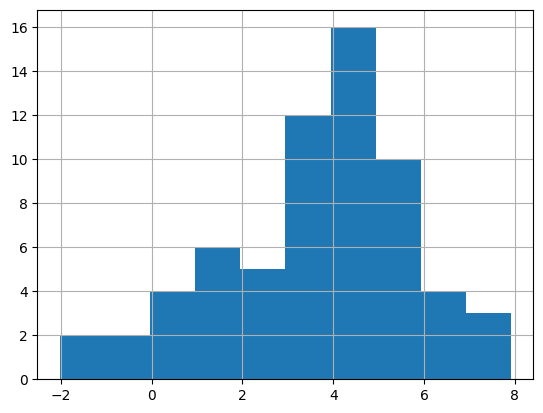

In [214]:
to_predict_mens_first_round_test['t2_top8_BPM_weighted_mean'].hist()

(3.777159203553301, 3.777159203553302, 1.874154037251757, 1.874154037251757)

(-0.2024805874864447, 0.2576928704331698)

array([[ 1.34118202, -1.9645251 , -1.70380897, ..., -0.29641378,
        -2.43262167,  0.58015062],
       [ 1.01314084, -1.3734627 ,  0.61117438, ...,  0.04334694,
        -1.7479007 ,  0.58015062],
       [ 0.04669638,  0.14244202,  0.98570277, ..., -0.00917262,
         0.58015062,  0.58015062],
       ...,
       [ 0.31802633,  0.20526461,  0.50861943, ...,  2.16665739,
         0.58015062, -1.06317972],
       [ 0.10855001, -0.16458397,  0.94405124, ..., -0.06311708,
         0.58015062,  0.58015062],
       [ 1.40148654, -0.86903513, -0.69653322, ..., -0.45313541,
         0.58015062,  0.58015062]])

In [193]:
statistics_model_first_round_features


['t1_top8_BPM_weighted_mean',
 't2_top8_BPM_weighted_mean',
 't1_top8_TO_stdev',
 't2_top8_TO_stdev',
 't1_top5_PRPG!_median',
 't2_top5_PRPG!_median',
 't1_top3_DR_median',
 't2_top3_DR_median',
 't1_top5_STL_cv',
 't2_top5_STL_cv',
 't1_top3_Min%_median',
 't2_top3_Min%_median',
 't1_top8_TS_gini',
 't2_top8_TS_gini',
 't1_top3_USG_gini',
 't2_top3_USG_gini',
 't1_OrdinalRank',
 't2_OrdinalRank']

(3.777159203553301, 3.777159203553302)

### Statistics Model Training

In [20]:
def train_statistics_model(to_predict_mens_train, statistics_features):

    best_params = {"C": .1}
    model = LogisticRegression(**best_params)
    pipeline = make_pipeline(StandardScaler(), model)
    statistics_model = pipeline.fit(to_predict_mens_train[statistics_features], to_predict_mens_train["Outcome"])

    return statistics_model


### Full Pipeline

In [146]:
SEASON = 2024

statistics_model_full_features = [   't1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean',
    't1_top8_TO_stdev', 't2_top8_TO_stdev',
    't1_top5_PRPG!_median', 't2_top5_PRPG!_median',
    't1_top3_DR_median', 't2_top3_DR_median',
    't1_top5_STL_cv', 't2_top5_STL_cv',
    't1_top3_Min%_median', 't2_top3_Min%_median',
    't1_top8_TS_gini', 't2_top8_TS_gini',
    't1_top3_USG_gini', 't2_top3_USG_gini',
    't1_OrdinalRank', 't2_OrdinalRank',
    't1_adj_margin', 't2_adj_margin', 
    ]

statistics_model_first_round_features = ['t1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean',
    't1_top8_TO_stdev', 't2_top8_TO_stdev',
    't1_top5_PRPG!_median', 't2_top5_PRPG!_median',
    't1_top3_DR_median', 't2_top3_DR_median',
    't1_top5_STL_cv', 't2_top5_STL_cv',
    't1_top3_Min%_median', 't2_top3_Min%_median',
    't1_top8_TS_gini', 't2_top8_TS_gini',
    't1_top3_USG_gini', 't2_top3_USG_gini',
    't1_OrdinalRank', 't2_OrdinalRank'
    ,]


# get data
to_predict_mens_first_round_train, to_predict_mens_train, to_predict_mens_first_round_test, to_predict_mens_other_rounds_test= prepare_data(to_predict_mens, SEASON)

# train
statistics_model_full = train_statistics_model(to_predict_mens_train, statistics_model_full_features)
statistics_model_first_round = train_statistics_model(to_predict_mens_first_round_train, statistics_model_first_round_features)

# inference
pred_proba = statistics_model_first_round.predict_proba(to_predict_mens_first_round_test[statistics_model_first_round_features].copy())[:,1]
to_predict_mens_first_round_test["Pred"] = pred_proba

pred_proba = statistics_model_full.predict_proba(to_predict_mens_other_rounds_test[statistics_model_full_features].copy())[:,1]
to_predict_mens_other_rounds_test["Pred"] = pred_proba

mens_sub_tmp = pd.concat([to_predict_mens_first_round_test,
        to_predict_mens_other_rounds_test], axis=0)

mens_sub = mens_sub_tmp[["ID", "Pred"]]


In [183]:
to_predict_mens_first_round_train["t1_top3_Min%_median"].mean(), to_predict_mens_first_round_train["t2_top3_Min%_median"].mean()

(75.8357740585774, 75.8357740585774)

### Womens

In [29]:
to_predict_women = pd.read_csv("to_predict_women.csv")

to_predict_women_train = to_predict_women[to_predict_women.Season != 2024] 
to_predict_women_test = to_predict_women[to_predict_women.Season == 2024] 


In [32]:
statistics_features = ['seed_diff', 't1_adj_margin', 't2_adj_margin']
best_params = {"C": .1}
model = LogisticRegression(**best_params)
pipeline = make_pipeline(StandardScaler(), model)
statistics_model = pipeline.fit(to_predict_women_train[statistics_features], to_predict_women_train["Outcome"])
pred_proba = statistics_model.predict_proba(to_predict_women_test[statistics_features].copy())[:,1]
to_predict_women_test["Pred_Baseline"] = pred_proba


/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_72087/889996954.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_predict_women_test["Pred_Baseline"] = pred_proba


In [30]:
SEASON = 2024

features = ['seed_diff', 
    't1_adj_margin', 't2_adj_margin',
    't1_top8_BPM_weighted_mean', 't2_top8_BPM_weighted_mean']

best_params = {"C": .1}

model = LogisticRegression(**best_params)
pipeline = make_pipeline(StandardScaler(), model)

to_predict_mens_train = to_predict_mens[(to_predict_mens.Season < SEASON)
                                            & (to_predict_mens.Season >= 2008)].copy()

statistics_model = pipeline.fit(to_predict_mens_train[features], to_predict_mens_train["Outcome"])
pred_proba = statistics_model.predict_proba(to_predict_women_test[features].copy())[:,1]

to_predict_women_test["Pred_New"] = pred_proba


/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_72087/3365922374.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_predict_women_test["Pred_New"] = pred_proba


In [33]:
to_predict_women_test["Pred"] = (to_predict_women_test["Pred_Baseline"] + to_predict_women_test["Pred_New"]) / 2

/var/folders/h5/f91pbgmj0rj6v0ls3y8zc5l40000gn/T/ipykernel_72087/1750293826.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  to_predict_women_test["Pred"] = (to_predict_women_test["Pred_Baseline"] + to_predict_women_test["Pred_New"]) / 2


In [34]:

womens_sub = to_predict_women_test[["ID", "Pred"]]


In [35]:
final_sub = pd.concat([mens_sub, womens_sub], axis=0)

In [161]:
final_sub.to_csv("traditional_format_sub.csv")

### Sanity Checks

In [147]:
to_predict_mens_first_round_test.shape


(64, 71)

In [148]:
mens_sub_tmp.columns

Index(['Unnamed: 0', 'type', 'ID', 'Pred', 'Season', 'Team1', 'Team2',
       'Outcome', 'Gender', 'margin', 't1_TeamName', 't1_FirstD1Season',
       't1_LastD1Season', 't2_TeamName', 't2_FirstD1Season', 't2_LastD1Season',
       'final_odds', 'GameRound', 't1_FGM', 't1_FGA', 't1_FGM3', 't1_FGA3',
       't1_OR', 't1_Ast', 't1_TO', 't1_Stl', 't1_PF', 't1_FTA', 't1_FTM',
       't1_PointDiff', 't2_FGM', 't2_FGA', 't2_FGM3', 't2_FGA3', 't2_OR',
       't2_Ast', 't2_TO', 't2_Stl', 't2_PF', 't2_FTA', 't2_FTM',
       't2_PointDiff', 't1_OrdinalRank', 't2_OrdinalRank', 't1_Seed',
       't2_Seed', 'seed_diff', 't1_adj_oe', 't1_adj_de', 't1_adj_margin',
       't2_adj_oe', 't2_adj_de', 't2_adj_margin', 't1_final_rank',
       't2_final_rank', 't1_top8_TO_stdev', 't1_top5_PRPG!_median',
       't1_top3_DR_median', 't1_top5_STL_cv', 't1_top3_Min%_median',
       't1_top8_TS_gini', 't1_top3_USG_gini', 't1_top8_BPM_weighted_mean',
       't2_top8_TO_stdev', 't2_top5_PRPG!_median', 't2_top3_DR_m

In [149]:
mens_sub_tmp[mens_sub_tmp.GameRound == 1][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', "GameRound"]].tail(15)

,Pred,Outcome,t1_TeamName,t2_TeamName,GameRound
2716,0.075026,0,Colgate,Baylor,1
2717,0.223636,0,New Mexico,Clemson,1
2718,0.629267,0,Florida,Colorado,1
2719,0.013424,0,Stetson,Connecticut,1
2720,0.074121,0,Vermont,Duke,1
2721,0.811025,0,St Mary's CA,Grand Canyon,1
2722,0.021255,0,Longwood,Houston,1
2723,0.482819,0,Wisconsin,James Madison,1
2724,0.082702,0,WKU,Marquette,1
2725,0.394904,0,FL Atlantic,Northwestern,1


In [366]:
mens_sub_tmp[mens_sub_tmp.t1_TeamName == "Duke"][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', "GameRound"]].tail(15)

,Pred,Outcome,t1_TeamName,t2_TeamName,GameRound
1339,0.925879,1,Duke,Vermont,1
1361,0.760145,1,Duke,James Madison,2
1370,0.165195,1,Duke,Houston,3
2757,0.713542,0,Duke,NC State,4


In [150]:
brier_score_loss(mens_sub_tmp["Outcome"], mens_sub_tmp["Pred"])

0.16198836126297914

In [349]:
# Round 1 correctness
round1_correctness = mens_sub_tmp[mens_sub_tmp.GameRound == 1][["Pred", "Outcome", 't1_TeamName', 't2_TeamName', 
                                                                "t1_Seed", "t2_Seed", "GameRound"]]
round1_correctness["Outcome_Pred"] = np.where(round1_correctness.Pred > .5, 1, 0 )
round1_correctness["Correct"] = np.where(round1_correctness["Outcome"] == round1_correctness["Outcome_Pred"], 1, 0)
round1_correctness["Correct"].mean()

0.75

In [360]:
round1_correctness[(
   (  (round1_correctness.t1_Seed >= 10) & (round1_correctness.Pred >= .20) )
)
].head(50)

,Pred,Outcome,t1_TeamName,t2_TeamName,t1_Seed,t2_Seed,GameRound,Outcome_Pred,Correct
1321,0.277548,1,Duquesne,BYU,11,6,1,0,0
1327,0.464633,1,NC State,Texas Tech,11,6,1,0,0
1330,0.538631,1,Oregon,South Carolina,11,6,1,1,1
1337,0.370733,1,Colorado,Florida,10,7,1,0,0
1342,0.517181,1,James Madison,Wisconsin,12,5,1,1,1
2701,0.621824,0,Nevada,Dayton,10,7,1,1,0
2714,0.560016,0,Drake,Washington St,10,7,1,1,0
2715,0.228810,0,Col Charleston,Alabama,13,4,1,0,1
2717,0.223636,0,New Mexico,Clemson,11,6,1,0,1
2727,0.248604,0,UAB,San Diego St,12,5,1,0,1


In [293]:
team_name = "Nebraska"

In [327]:
mens_sub_tmp[(mens_sub_tmp.t1_TeamName == "Nebraska")][statistics_model_first_round_features]#.iloc[:,0].tolist()

,t1_top8_BPM_weighted_mean,t2_top8_BPM_weighted_mean,t1_top8_TO_stdev,t2_top8_TO_stdev,t1_top5_PRPG!_median,t2_top5_PRPG!_median,t1_top3_DR_median,t2_top3_DR_median,t1_top5_STL_cv,t2_top5_STL_cv,t1_top3_Min%_median,t2_top3_Min%_median,t1_top8_TS_gini,t2_top8_TS_gini,t1_top3_USG_gini,t2_top3_USG_gini,t1_OrdinalRank,t2_OrdinalRank
2728,4.372878,4.161655,5.122926,3.332792,3.1,3.5,15.6,13.1,0.304446,0.37424,69.1,71.1,0.037684,0.075446,0.018173,0.1801,25.0,13.0


In [341]:
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_impact(features, values, coefficients, figsize=(10, 6),
                          title="Feature Impact (Value x Coefficient)"):
    """
    Plots the impact of each feature by multiplying its value with its coefficient.

    Parameters:
        features (list of str): Names of the features.
        values (list of float): The values for each feature (e.g., for a given sample).
        coefficients (list of float): The logistic regression coefficients.
        figsize (tuple): Size of the figure.
        title (str): Title for the plot.
    """
    if not (len(features) == len(values) == len(coefficients)):
        raise ValueError("All input lists (features, values, coefficients) must have the same length.")
    
    # Convert to numpy arrays for easy manipulation
    features = np.array(features)
    values = np.array(values)
    coefficients = np.array(coefficients)
    
    # Calculate impact for each feature
    impacts = values * coefficients
    
    # Sort features by the absolute impact in descending order
    sorted_indices = np.argsort(np.abs(impacts))[::-1]
    sorted_features = features[sorted_indices]
    sorted_impacts = impacts[sorted_indices]
    
    # Create colors: blue for positive, red for negative
    colors = ['blue' if impact >= 0 else 'red' for impact in sorted_impacts]
    
    # Plotting
    plt.figure(figsize=figsize)
    bars = plt.barh(sorted_features, sorted_impacts, color=colors)
    plt.xlabel("Impact (Feature Value x Coefficient)")
    plt.title(title)
    plt.axvline(0, color='black', linewidth=1)  # vertical line at zero

    # Annotate each bar with the impact value
    max_impact = np.abs(sorted_impacts).max() if np.abs(sorted_impacts).max() != 0 else 1
    x_offset = 0.02 * max_impact
    for bar in bars:
        width = bar.get_width()
        xpos = width + x_offset if width >= 0 else width - x_offset
        ha = 'left' if width >= 0 else 'right'
        plt.text(xpos, bar.get_y() + bar.get_height()/2, f'{width:.2f}', va='center', ha=ha, color='black')
    
    plt.gca().invert_yaxis()  # highest impact at the top
    plt.tight_layout()
    plt.show()




In [342]:
def analyze_first_round_game(t1_team_name):
    scaler = statistics_model_first_round.named_steps['standardscaler']
    scaled_feature_names = ["scaled_" + feature for feature in statistics_model_first_round_features]
    mens_sub_tmp[scaled_feature_names] = scaler.transform(mens_sub_tmp[statistics_model_first_round_features])
    raw_values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name)][statistics_model_first_round_features].transpose().iloc[:,0].tolist()
    values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name)][scaled_feature_names].transpose().iloc[:,0].tolist()
    coef_list = statistics_model_first_round.named_steps['logisticregression'].coef_.tolist()[0]
    df_analysis = pd.DataFrame(list(zip(coef_list, raw_values_list, values_list)), columns = ["model_coef", "raw_feature_value", 
    "feature_value"])
    df_analysis["feature_name"] = statistics_model_first_round_features
    df_analysis["impact"] = df_analysis.model_coef * df_analysis.feature_value
    df_analysis["abs_impact"] = np.abs(df_analysis["impact"])
    df_analysis.sort_values(by="abs_impact", ascending=False)

    net_weighted_values = sum(x * y for x, y in zip(values_list, coef_list))

    print(f"net weighted value: {net_weighted_values}")

    plot_feature_impact(statistics_model_first_round_features, values_list, coef_list)

    return df_analysis[["feature_name", "raw_feature_value", "feature_value",
                        "model_coef", "impact", "abs_impact"]].sort_values(by="abs_impact", ascending=False)

In [362]:
def analyze_non_first_round_game(t1_team_name, t2_team_name):
    scaler = statistics_model_full.named_steps['standardscaler']
    scaled_feature_names = ["scaled_" + feature for feature in statistics_model_full_features]
    mens_sub_tmp[scaled_feature_names] = scaler.transform(mens_sub_tmp[statistics_model_full_features])
    raw_values_list = mens_sub_tmp[
        (mens_sub_tmp.t1_TeamName == t1_team_name) & (mens_sub_tmp.t2_TeamName == t2_team_name)][statistics_model_full_features].transpose().iloc[:,0].tolist()
    values_list = mens_sub_tmp[(mens_sub_tmp.t1_TeamName == t1_team_name) & (mens_sub_tmp.t2_TeamName == t2_team_name)][scaled_feature_names].transpose().iloc[:,0].tolist()
    coef_list = statistics_model_full.named_steps['logisticregression'].coef_.tolist()[0]
    df_analysis = pd.DataFrame(list(zip(coef_list, raw_values_list, values_list)), columns = ["model_coef", "raw_feature_value", 
    "feature_value"])
    df_analysis["feature_name"] = statistics_model_full_features
    df_analysis["impact"] = df_analysis.model_coef * df_analysis.feature_value
    df_analysis["abs_impact"] = np.abs(df_analysis["impact"])
    df_analysis.sort_values(by="abs_impact", ascending=False)

    net_weighted_values = sum(x * y for x, y in zip(values_list, coef_list))

    print(f"net weighted value: {net_weighted_values}")

    plot_feature_impact(statistics_model_full_features, values_list, coef_list)

    return df_analysis[["feature_name", "raw_feature_value", "feature_value",
                        "model_coef", "impact", "abs_impact"]].sort_values(by="abs_impact", ascending=False)

net weighted value: 0.9126483996342238


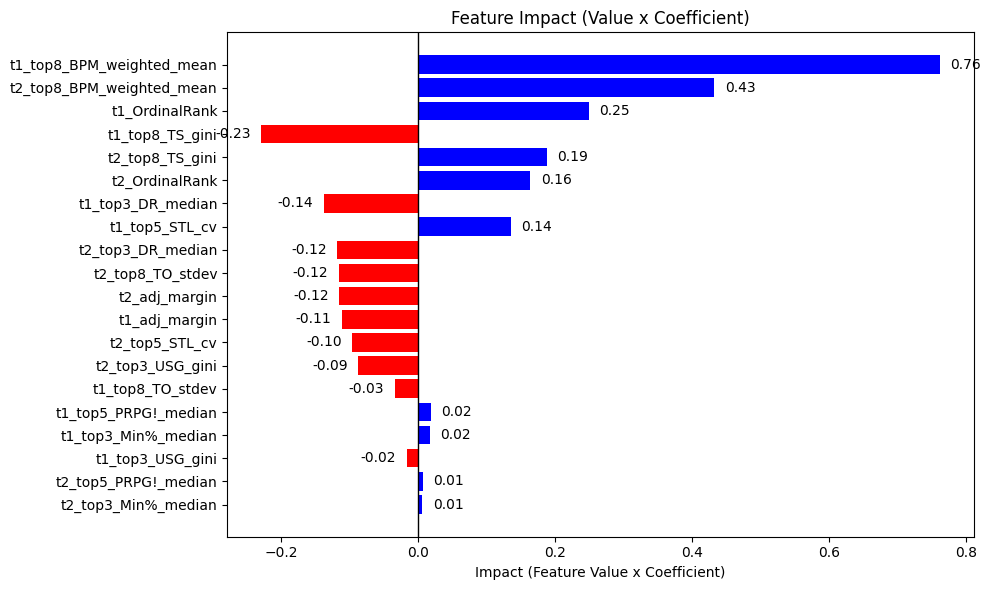

,feature_name,raw_feature_value,feature_value,model_coef,impact,abs_impact
0,t1_top8_BPM_weighted_mean,5.836741,0.774244,0.982932,0.761029,0.761029
1,t2_top8_BPM_weighted_mean,3.456566,-0.439812,-0.982932,0.432305,0.432305
16,t1_OrdinalRank,9.000000,-1.132135,-0.219440,0.248436,0.248436
12,t1_top8_TS_gini,0.020407,-1.863723,0.122877,-0.229008,0.229008
13,t2_top8_TS_gini,0.025883,-1.529943,-0.122877,0.187994,0.187994
17,t2_OrdinalRank,25.000000,0.744315,0.219440,0.163333,0.163333
6,t1_top3_DR_median,15.300000,1.142186,-0.120698,-0.137860,0.137860
8,t1_top5_STL_cv,0.183821,-1.162774,-0.116224,0.135142,0.135142
7,t2_top3_DR_median,9.400000,-0.978755,0.120698,-0.118134,0.118134
3,t2_top8_TO_stdev,3.366007,-0.653918,0.177264,-0.115916,0.115916


In [365]:
analyze_non_first_round_game("Duke", "NC State")